# DFL differentiable pipeline diagnostic

This notebook isolates the downstream differentiable decision layer required for Decision-Focused Learning before connecting it to a forecasting model.

The computational graph is:

```text
z -> PD^Q -> PD^A -> K_IRB -> E[U(alpha)] -> alpha_soft -> L_DFL
```

The goal is to verify that a finite and meaningful gradient can flow from the realised DFL loss back to the predicted quarterly PD.

This notebook does **not** train a macroeconomic forecasting model. It diagnoses only the decision layer:

```text
predicted quarterly PD
-> annualised PD for Basel IRB
-> Vasicek Monte Carlo charge-off distribution
-> expected utility over an allocation grid
-> differentiable soft allocation
-> realised utility under realised quarterly charge-offs
-> DFL loss
```

Main conceptual conventions:

- The model output is quarterly PD, not annual PD.
- Annual PD is used only inside Basel IRB and Vasicek annual default-rate calculations.
- Simulated annual default rates are converted back to quarterly default/charge-off rates before utility.
- The realised DFL loss evaluates the selected allocation against realised quarterly charge-offs.
- The shortfall penalty is linear: `U = K_2 - lambda * S`, not squared.

For this initial diagnostic, realised utility uses the predicted PD-based IRB capital requirement. A later robustness notebook may evaluate realised consequences using a true or realised PD-based capital requirement, but that alternative is intentionally not implemented here.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Iterable, Tuple

import math
import random

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import torch

DTYPE = torch.float64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@dataclass(frozen=True)
class DiagnosticConfig:
    LGD: float = 0.45
    M: float = 2.5
    CONFIDENCE_LEVEL: float = 0.999
    LEVERAGE: float = 5.0
    Y_BAR: float = 0.0168
    LAMBDA_SHORTFALL: float = 10.0
    PD_EPS: float = 1e-5
    N_ALPHA: int = 101
    N_MC: int = 10_000
    TEMPERATURE: float = 0.02
    SEED: int = 42

cfg = DiagnosticConfig()

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print(f"device={DEVICE}, dtype={DTYPE}")
print(cfg)

device=cpu, dtype=torch.float64
DiagnosticConfig(LGD=0.45, M=2.5, CONFIDENCE_LEVEL=0.999, LEVERAGE=5.0, Y_BAR=0.0168, LAMBDA_SHORTFALL=10.0, PD_EPS=1e-05, N_ALPHA=101, N_MC=10000, TEMPERATURE=0.02, SEED=42)


## Configuration and units

All rates are decimals, not percentages.

- `PD^Q` is quarterly predicted probability of default.
- `PD^A = 1 - (1 - PD^Q)^4` is annualised only for IRB and Vasicek annual default-rate calculations.
- Monte Carlo annual default rates are converted back to quarterly default rates.
- Quarterly charge-off rates are `LGD * DR_Q`.
- `Y_BAR` is a quarterly loan yield.
- Realised charge-offs used in the final loss are quarterly rates.

The allocation grid is used to evaluate candidate decisions. The training allocation is **not** a hard argmax: it is a softmax-weighted allocation, so gradients can flow back to `PD^Q`.

In [2]:
def to_tensor(value: float, like: torch.Tensor | None = None) -> torch.Tensor:
    """Create a scalar tensor on the diagnostic dtype/device, optionally matching another tensor."""
    if like is None:
        return torch.tensor(value, dtype=DTYPE, device=DEVICE)
    return torch.tensor(value, dtype=like.dtype, device=like.device)


def standard_normal(dtype: torch.dtype = DTYPE, device: torch.device = DEVICE) -> torch.distributions.Normal:
    """Standard normal distribution with tensor parameters."""
    return torch.distributions.Normal(
        torch.tensor(0.0, dtype=dtype, device=device),
        torch.tensor(1.0, dtype=dtype, device=device),
    )


def assert_finite(name: str, tensor: torch.Tensor) -> None:
    """Assert a tensor contains only finite values."""
    assert torch.isfinite(tensor).all(), f"{name} contains NaNs or infinities"


def tensor_to_numpy(tensor: torch.Tensor) -> np.ndarray:
    """Detach tensor for plotting only; never use inside differentiable functions."""
    return tensor.detach().cpu().numpy()


alpha_grid = torch.linspace(0.0, 1.0, cfg.N_ALPHA, dtype=DTYPE, device=DEVICE)
mc_shocks = torch.randn(cfg.N_MC, dtype=DTYPE, device=DEVICE)
print(alpha_grid.shape, mc_shocks.shape)

torch.Size([101]) torch.Size([10000])


## Differentiable Basel functions

These functions are implemented in PyTorch and are intended to be safe for autograd. They do not use NumPy, SciPy, `.detach()`, `.item()`, or Python scalar conversion inside the differentiable path.

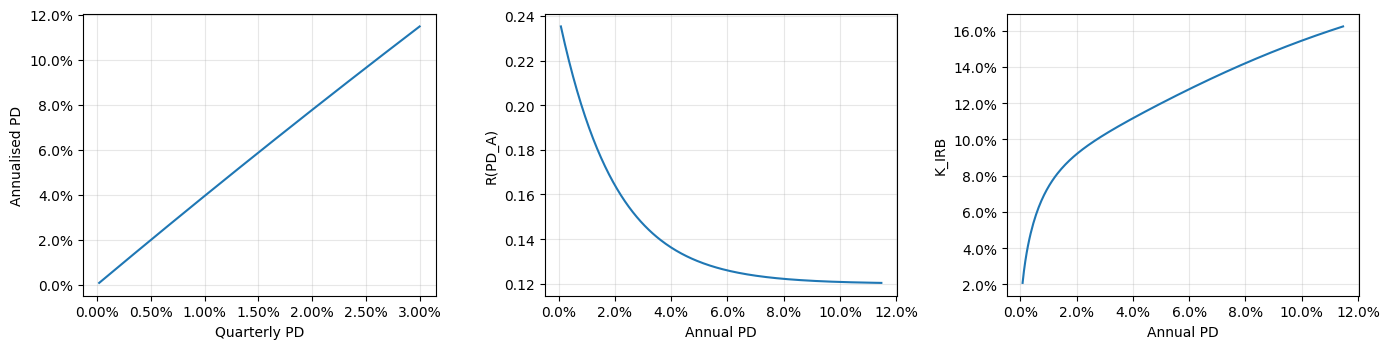

In [3]:
def bounded_quarterly_pd_from_logits(z: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Smoothly map unconstrained logits to quarterly PD in (eps, 1-eps)."""
    eps = to_tensor(config.PD_EPS, z)
    return eps + (1.0 - 2.0 * eps) * torch.sigmoid(z)


def quarterly_pd_to_annual_pd(pd_q: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Convert quarterly PD to annual PD: PD_A = 1 - (1 - PD_Q)^4."""
    return 1.0 - torch.pow(1.0 - pd_q, 4.0)


def annual_default_rate_to_quarterly(dr_a: torch.Tensor) -> torch.Tensor:
    """Convert annual default rate to equivalent quarterly default rate."""
    return 1.0 - torch.pow(1.0 - dr_a, 0.25)


def irb_asset_correlation(pd_a: torch.Tensor) -> torch.Tensor:
    """Basel corporate IRB asset correlation R(PD), with annual PD input."""
    exp_term = (1.0 - torch.exp(-50.0 * pd_a)) / (1.0 - torch.exp(to_tensor(-50.0, pd_a)))
    return 0.12 * exp_term + 0.24 * (1.0 - exp_term)


def irb_maturity_adjustment(pd_a: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Basel IRB maturity adjustment MA(PD), with annual PD input."""
    b = torch.square(0.11852 - 0.05478 * torch.log(pd_a))
    return (1.0 + (config.M - 2.5) * b) / (1.0 - 1.5 * b)


def k_irb_from_annual_pd_torch(pd_a: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Basel IRB capital per unit exposure. Input must be annual PD."""
    normal = standard_normal(dtype=pd_a.dtype, device=pd_a.device)
    r = irb_asset_correlation(pd_a)
    z = normal.icdf(pd_a) / torch.sqrt(1.0 - r)
    z = z + torch.sqrt(r / (1.0 - r)) * normal.icdf(to_tensor(config.CONFIDENCE_LEVEL, pd_a))
    ma = irb_maturity_adjustment(pd_a, config)
    k_irb = config.LGD * (normal.cdf(z) - pd_a) * ma
    return torch.relu(k_irb)


pd_q_grid = torch.linspace(0.0002, 0.03, 250, dtype=DTYPE, device=DEVICE)
pd_a_grid = quarterly_pd_to_annual_pd(pd_q_grid)
r_grid = irb_asset_correlation(pd_a_grid)
k_grid = k_irb_from_annual_pd_torch(pd_a_grid)

for name, value in {"pd_a_grid": pd_a_grid, "r_grid": r_grid, "k_grid": k_grid}.items():
    assert_finite(name, value)
assert (pd_a_grid > 0).all() and (pd_a_grid < 1).all()
assert (k_grid >= 0).all()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(tensor_to_numpy(pd_q_grid), tensor_to_numpy(pd_a_grid))
axes[0].set_xlabel("Quarterly PD")
axes[0].set_ylabel("Annualised PD")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].plot(tensor_to_numpy(pd_a_grid), tensor_to_numpy(r_grid))
axes[1].set_xlabel("Annual PD")
axes[1].set_ylabel("R(PD_A)")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].plot(tensor_to_numpy(pd_a_grid), tensor_to_numpy(k_grid))
axes[2].set_xlabel("Annual PD")
axes[2].set_ylabel("K_IRB")
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Vasicek Monte Carlo charge-off simulation

The function below accepts a batch of predicted quarterly PD values and fixed standard-normal systematic shocks. It returns simulated quarterly charge-off rates with shape `[batch_size, n_mc]`.

Common random numbers are used by passing the same `mc_shocks` tensor whenever comparing allocations, nearby PD values, temperatures, or finite differences.

shape: (4, 10000)
means: [0.000904   0.00227484 0.00456446 0.00916675]
mins: [3.89363157e-07 6.76959836e-06 5.01703822e-05 2.38253120e-04]
maxs: [0.02286684 0.03252134 0.04218123 0.05968804]


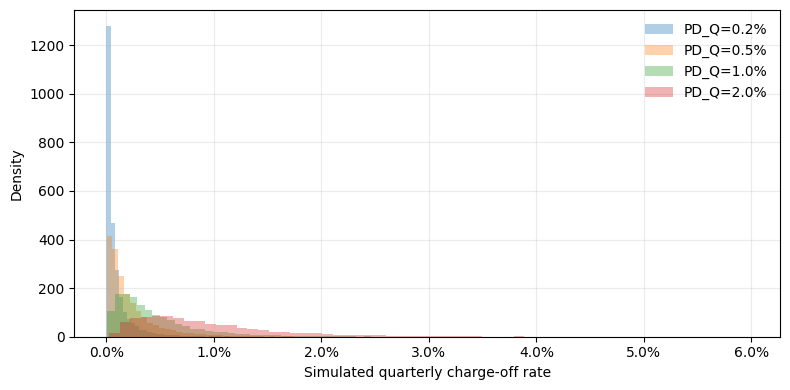

In [4]:
def vasicek_quarterly_chargeoffs(
    pd_q: torch.Tensor,
    shocks: torch.Tensor,
    config: DiagnosticConfig = cfg,
) -> torch.Tensor:
    """Simulate quarterly charge-off rates from predicted quarterly PD.

    Shapes:
    - pd_q: [batch]
    - shocks: [n_mc]
    - output c_q_mc: [batch, n_mc]
    """
    normal = standard_normal(dtype=pd_q.dtype, device=pd_q.device)
    pd_a = quarterly_pd_to_annual_pd(pd_q, config)  # [B]
    r = irb_asset_correlation(pd_a)                 # [B]
    numerator = normal.icdf(pd_a)[:, None] - torch.sqrt(r)[:, None] * shocks[None, :]
    denominator = torch.sqrt(1.0 - r)[:, None]
    dr_a = normal.cdf(numerator / denominator)      # [B, M]
    dr_q = annual_default_rate_to_quarterly(dr_a)   # [B, M]
    return config.LGD * dr_q


pd_examples = torch.tensor([0.002, 0.005, 0.010, 0.020], dtype=DTYPE, device=DEVICE)
c_mc_examples = vasicek_quarterly_chargeoffs(pd_examples, mc_shocks)
assert c_mc_examples.shape == (pd_examples.shape[0], mc_shocks.shape[0])
assert_finite("c_mc_examples", c_mc_examples)
assert (c_mc_examples >= 0).all()
print("shape:", tuple(c_mc_examples.shape))
print("means:", tensor_to_numpy(c_mc_examples.mean(dim=1)))
print("mins:", tensor_to_numpy(c_mc_examples.min(dim=1).values))
print("maxs:", tensor_to_numpy(c_mc_examples.max(dim=1).values))

fig, ax = plt.subplots(figsize=(8, 4))
for idx, pd_level in enumerate(pd_examples):
    ax.hist(
        tensor_to_numpy(c_mc_examples[idx]),
        bins=60,
        density=True,
        alpha=0.35,
        label=f"PD_Q={float(pd_level):.1%}",
    )
ax.set_xlabel("Simulated quarterly charge-off rate")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(frameon=False)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Utility and shortfall functions

Expected tensor shapes:

- `alpha`: `[n_alpha]`, `[batch, n_alpha, 1]`, or any broadcast-compatible shape
- `c_q`: `[batch, n_mc]`, `[batch, 1, n_mc]`, or broadcast-compatible realised/MC charge-offs
- `k_irb`: `[batch]`, `[batch, 1, 1]`, or broadcast-compatible capital requirement

The implementation is vectorised across batch, allocation grid, and Monte Carlo dimensions.

In [5]:
def exposure(alpha: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Exposure E = leverage * alpha * K1, with K1=1."""
    return config.LEVERAGE * alpha


def terminal_capital(alpha: torch.Tensor, c_q: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Terminal capital K2 = K1 + exposure * (y_bar - c_q)."""
    return 1.0 + exposure(alpha, config) * (config.Y_BAR - c_q)


def available_buffer(alpha: torch.Tensor, c_q: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Available buffer B = K2 - alpha*K1."""
    return terminal_capital(alpha, c_q, config) - alpha


def required_capital(alpha: torch.Tensor, k_irb: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Required capital = K_IRB(PD_A) * exposure."""
    return k_irb * exposure(alpha, config)


def shortfall(alpha: torch.Tensor, c_q: torch.Tensor, k_irb: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Linear positive-part shortfall S = relu(K_req - B)."""
    return torch.relu(required_capital(alpha, k_irb, config) - available_buffer(alpha, c_q, config))


def utility(alpha: torch.Tensor, c_q: torch.Tensor, k_irb: torch.Tensor, config: DiagnosticConfig = cfg) -> torch.Tensor:
    """Utility U = K2 - lambda*S. The shortfall penalty is linear, not squared."""
    s = shortfall(alpha, c_q, k_irb, config)
    return terminal_capital(alpha, c_q, config) - config.LAMBDA_SHORTFALL * s


# Broadcasting sanity check: [B, A, M]
pd_a_examples = quarterly_pd_to_annual_pd(pd_examples)
k_examples = k_irb_from_annual_pd_torch(pd_a_examples)
u_check = utility(
    alpha_grid[None, :, None],
    c_mc_examples[:, None, :],
    k_examples[:, None, None],
)
assert u_check.shape == (pd_examples.shape[0], cfg.N_ALPHA, cfg.N_MC)
assert_finite("u_check", u_check)
print("utility broadcast shape:", tuple(u_check.shape))

utility broadcast shape: (4, 101, 10000)


## Expected utility over the allocation grid

For each predicted quarterly PD observation, the decision layer computes Monte Carlo expected utility for every candidate allocation.

Output shape is `[batch_size, n_alpha]`.

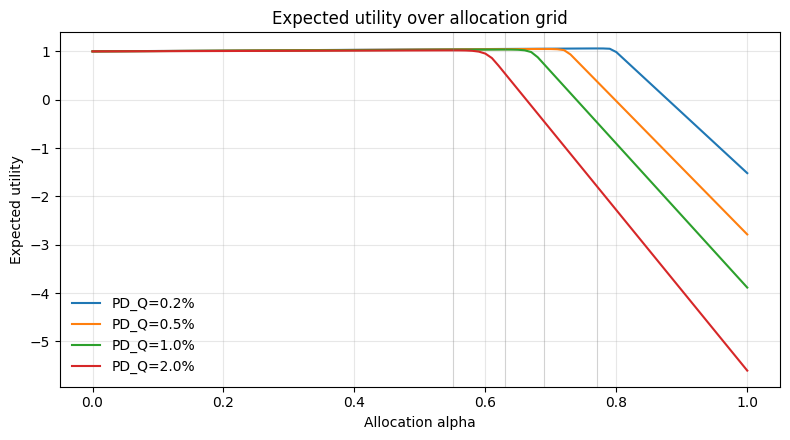

In [6]:
def expected_utility_grid(
    pd_q: torch.Tensor,
    alpha_grid_in: torch.Tensor,
    shocks: torch.Tensor,
    config: DiagnosticConfig = cfg,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute expected utility over an allocation grid.

    Returns:
    - expected utility: [batch, n_alpha]
    - simulated quarterly charge-offs: [batch, n_mc]
    - annual PD: [batch]
    - K_IRB: [batch]
    """
    pd_a = quarterly_pd_to_annual_pd(pd_q, config)
    k_irb = k_irb_from_annual_pd_torch(pd_a, config)
    c_q_mc = vasicek_quarterly_chargeoffs(pd_q, shocks, config)
    u = utility(alpha_grid_in[None, :, None], c_q_mc[:, None, :], k_irb[:, None, None], config)
    return u.mean(dim=2), c_q_mc, pd_a, k_irb


def hard_allocation_from_expected_utility(eu_grid: torch.Tensor, alpha_grid_in: torch.Tensor) -> torch.Tensor:
    """Hard grid optimum for evaluation only. Do not use this in the training path."""
    idx = torch.argmax(eu_grid, dim=1)
    return alpha_grid_in[idx]


pd_plot = torch.tensor([0.002, 0.005, 0.010, 0.020], dtype=DTYPE, device=DEVICE)
eu_plot, _, _, _ = expected_utility_grid(pd_plot, alpha_grid, mc_shocks)
assert eu_plot.shape == (pd_plot.shape[0], cfg.N_ALPHA)
assert_finite("eu_plot", eu_plot)

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, pd_level in enumerate(pd_plot):
    eu_i = eu_plot[i]
    hard_alpha = hard_allocation_from_expected_utility(eu_i[None, :], alpha_grid)[0]
    ax.plot(tensor_to_numpy(alpha_grid), tensor_to_numpy(eu_i), label=f"PD_Q={float(pd_level):.1%}")
    ax.axvline(float(hard_alpha), color="grey", lw=0.8, alpha=0.35)
ax.set_xlabel("Allocation alpha")
ax.set_ylabel("Expected utility")
ax.set_title("Expected utility over allocation grid")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Differentiable soft allocation

The hard grid optimum is useful for diagnostics, but the training allocation must be differentiable. The soft allocation is:

```text
w_j = softmax(E[U(alpha_j)] / tau)
alpha_soft = sum_j w_j alpha_j
```

Smaller temperatures move the soft allocation closer to the hard optimum, but can also create sharper gradients.

,temperature,pd_q,alpha_hard,alpha_soft,abs_gap
0,0.10,0.002,0.77,0.440408,0.329592
1,0.10,0.005,0.69,0.392757,0.297243
2,0.10,0.010,0.63,0.356257,0.273743
3,0.10,0.020,0.55,0.308605,0.241395
4,0.05,0.002,0.77,0.477769,0.292231
5,0.05,0.005,0.69,0.420166,0.269834
6,0.05,0.010,0.63,0.374807,0.255193
7,0.05,0.020,0.55,0.315640,0.234360
8,0.02,0.002,0.77,0.574148,0.195852
9,0.02,0.005,0.69,0.495351,0.194649


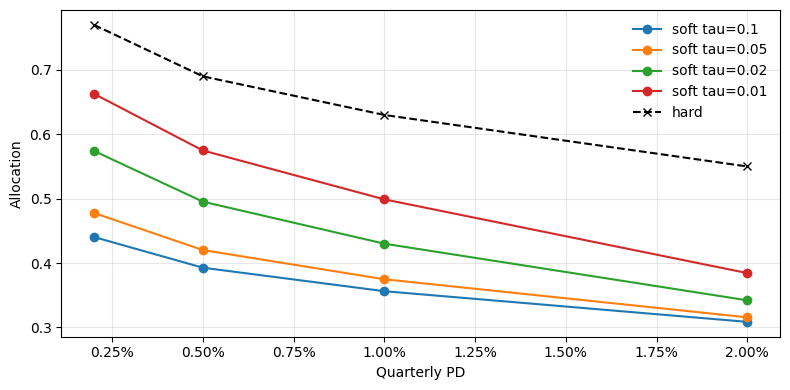

In [7]:
def soft_allocation_from_expected_utility(
    eu_grid: torch.Tensor,
    alpha_grid_in: torch.Tensor,
    temperature: float,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Return soft allocation and softmax weights from expected utility grid.

    Shapes:
    - eu_grid: [batch, n_alpha]
    - alpha_grid_in: [n_alpha]
    - alpha_soft: [batch]
    - weights: [batch, n_alpha]
    """
    weights = torch.softmax(eu_grid / temperature, dim=1)
    alpha_soft = torch.sum(weights * alpha_grid_in[None, :], dim=1)
    return alpha_soft, weights


temperatures = [0.1, 0.05, 0.02, 0.01]
rows = []
for tau in temperatures:
    alpha_soft, weights = soft_allocation_from_expected_utility(eu_plot, alpha_grid, tau)
    alpha_hard = hard_allocation_from_expected_utility(eu_plot, alpha_grid)
    assert_finite(f"weights tau={tau}", weights)
    assert torch.allclose(weights.sum(dim=1), torch.ones(pd_plot.shape[0], dtype=DTYPE, device=DEVICE), atol=1e-10)
    assert ((alpha_soft >= 0.0) & (alpha_soft <= 1.0)).all()
    for i, pd_level in enumerate(pd_plot):
        rows.append({
            "temperature": tau,
            "pd_q": float(pd_level),
            "alpha_hard": float(alpha_hard[i]),
            "alpha_soft": float(alpha_soft[i]),
            "abs_gap": float(torch.abs(alpha_soft[i] - alpha_hard[i])),
        })

allocation_table = pd.DataFrame(rows)
display(allocation_table)

fig, ax = plt.subplots(figsize=(8, 4))
for tau in temperatures:
    sub = allocation_table[allocation_table["temperature"] == tau]
    ax.plot(sub["pd_q"], sub["alpha_soft"], marker="o", label=f"soft tau={tau}")
ax.plot(sub["pd_q"], sub["alpha_hard"], color="black", linestyle="--", marker="x", label="hard")
ax.set_xlabel("Quarterly PD")
ax.set_ylabel("Allocation")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## End-to-end gradient test

We manually specify predicted quarterly PD values and realised quarterly charge-off rates, then run the complete pipeline:

```text
PD_Q -> PD_A -> K_IRB -> simulated charge-offs -> expected utility grid
-> soft allocation -> realised utility -> mean DFL loss
```

The allocation is selected using predicted PD. The final loss evaluates that selected allocation against realised quarterly charge-offs.

In [8]:
def realised_dfl_loss_from_pd_q(
    pd_q: torch.Tensor,
    c_realised_q: torch.Tensor,
    alpha_grid_in: torch.Tensor,
    shocks: torch.Tensor,
    temperature: float,
    config: DiagnosticConfig = cfg,
) -> Dict[str, torch.Tensor]:
    """Complete differentiable DFL decision pipeline for diagnostic use.

    Returns tensors needed for diagnostics. The loss is mean(-realised utility).
    """
    eu_grid, c_q_mc, pd_a, k_irb = expected_utility_grid(pd_q, alpha_grid_in, shocks, config)
    alpha_soft, weights = soft_allocation_from_expected_utility(eu_grid, alpha_grid_in, temperature)
    alpha_hard = hard_allocation_from_expected_utility(eu_grid, alpha_grid_in)
    realised_u = utility(alpha_soft, c_realised_q, k_irb, config)
    loss = -realised_u.mean()
    return {
        "loss": loss,
        "pd_q": pd_q,
        "pd_a": pd_a,
        "k_irb": k_irb,
        "c_q_mc": c_q_mc,
        "eu_grid": eu_grid,
        "weights": weights,
        "alpha_soft": alpha_soft,
        "alpha_hard": alpha_hard,
        "c_realised_q": c_realised_q,
        "realised_utility": realised_u,
    }


pd_q_manual = torch.tensor([0.002, 0.005, 0.010, 0.020], dtype=DTYPE, device=DEVICE, requires_grad=True)
c_realised_manual = torch.tensor([0.0010, 0.0025, 0.0060, 0.0140], dtype=DTYPE, device=DEVICE)
outputs = realised_dfl_loss_from_pd_q(pd_q_manual, c_realised_manual, alpha_grid, mc_shocks, cfg.TEMPERATURE)

for name, value in outputs.items():
    if isinstance(value, torch.Tensor):
        assert_finite(name, value)
outputs["loss"].backward()

assert pd_q_manual.grad is not None
assert_finite("pd_q_manual.grad", pd_q_manual.grad)
assert not torch.allclose(pd_q_manual.grad, torch.zeros_like(pd_q_manual.grad))

summary = pd.DataFrame({
    "pd_q": tensor_to_numpy(outputs["pd_q"]),
    "pd_a": tensor_to_numpy(outputs["pd_a"]),
    "k_irb": tensor_to_numpy(outputs["k_irb"]),
    "alpha_soft": tensor_to_numpy(outputs["alpha_soft"]),
    "alpha_hard": tensor_to_numpy(outputs["alpha_hard"]),
    "c_realised_q": tensor_to_numpy(outputs["c_realised_q"]),
    "realised_utility": tensor_to_numpy(outputs["realised_utility"]),
    "d_loss_d_pd_q": tensor_to_numpy(pd_q_manual.grad),
})
print("DFL loss:", float(outputs["loss"].detach().cpu()))
display(summary)

DFL loss: -1.027196984273282


,pd_q,pd_a,k_irb,alpha_soft,alpha_hard,c_realised_q,realised_utility,d_loss_d_pd_q
0,0.002,0.007976,0.067853,0.574148,0.77,0.0010,1.045358,0.684752
1,0.005,0.019850,0.091690,0.495351,0.69,0.0025,1.035418,0.301107
2,0.010,0.039404,0.111156,0.430065,0.63,0.0060,1.023223,0.145832
3,0.020,0.077632,0.140441,0.342083,0.55,0.0140,1.004789,0.024935


## Finite-difference gradient check

This compares the PyTorch autograd derivative against a central finite-difference approximation using the same fixed Vasicek shocks for both evaluations.

In [9]:
def scalar_loss_for_pd_value(
    pd_q_value: torch.Tensor,
    c_realised_q: torch.Tensor,
    alpha_grid_in: torch.Tensor,
    shocks: torch.Tensor,
    temperature: float,
    config: DiagnosticConfig = cfg,
) -> torch.Tensor:
    """Scalar DFL loss for one PD value, used for finite-difference diagnostics."""
    pd_q_batch = pd_q_value.reshape(1)
    c_batch = c_realised_q.reshape(1)
    return realised_dfl_loss_from_pd_q(pd_q_batch, c_batch, alpha_grid_in, shocks, temperature, config)["loss"]


def finite_difference_check(
    pd_q_scalar: float,
    c_realised_scalar: float,
    temperature: float,
    eps: float = 1e-5,
) -> Dict[str, float]:
    """Compare autograd and central finite-difference derivatives for one scalar PD."""
    pd_autograd = torch.tensor(pd_q_scalar, dtype=DTYPE, device=DEVICE, requires_grad=True)
    c_realised = torch.tensor(c_realised_scalar, dtype=DTYPE, device=DEVICE)
    loss = scalar_loss_for_pd_value(pd_autograd, c_realised, alpha_grid, mc_shocks, temperature)
    loss.backward()
    autograd_deriv = pd_autograd.grad.detach()

    pd_plus = torch.tensor(pd_q_scalar + eps, dtype=DTYPE, device=DEVICE)
    pd_minus = torch.tensor(pd_q_scalar - eps, dtype=DTYPE, device=DEVICE)
    loss_plus = scalar_loss_for_pd_value(pd_plus, c_realised, alpha_grid, mc_shocks, temperature)
    loss_minus = scalar_loss_for_pd_value(pd_minus, c_realised, alpha_grid, mc_shocks, temperature)
    fd_deriv = (loss_plus - loss_minus) / (2.0 * eps)

    abs_diff = torch.abs(autograd_deriv - fd_deriv)
    rel_diff = abs_diff / torch.clamp(torch.abs(fd_deriv), min=to_tensor(1e-12, fd_deriv))
    return {
        "temperature": temperature,
        "pd_q": pd_q_scalar,
        "c_realised_q": c_realised_scalar,
        "autograd_derivative": float(autograd_deriv.cpu()),
        "finite_difference_derivative": float(fd_deriv.detach().cpu()),
        "absolute_difference": float(abs_diff.detach().cpu()),
        "relative_difference": float(rel_diff.detach().cpu()),
    }


fd_rows = [finite_difference_check(0.008, 0.004, tau) for tau in temperatures]
fd_table = pd.DataFrame(fd_rows)
display(fd_table)
finite_difference_check_passed = bool((fd_table["relative_difference"] < 5e-2).all() | (fd_table["absolute_difference"] < 1e-5).all())
print("finite difference check passed:", finite_difference_check_passed)

,temperature,pd_q,c_realised_q,autograd_derivative,finite_difference_derivative,absolute_difference,relative_difference
0,0.10,0.008,0.004,0.423303,0.423297,0.000006,0.000014
1,0.05,0.008,0.004,0.536066,0.536041,0.000025,0.000047
2,0.02,0.008,0.004,0.777453,0.777329,0.000123,0.000159
3,0.01,0.008,0.004,0.915158,0.914796,0.000362,0.000396


finite difference check passed: True


## Gradient sensitivity plots

These plots diagnose whether the soft allocation gives usable gradients across a relevant quarterly PD range. They help identify zero-gradient regions, overly sharp gradients, unstable temperatures, and hard-allocation discontinuities.

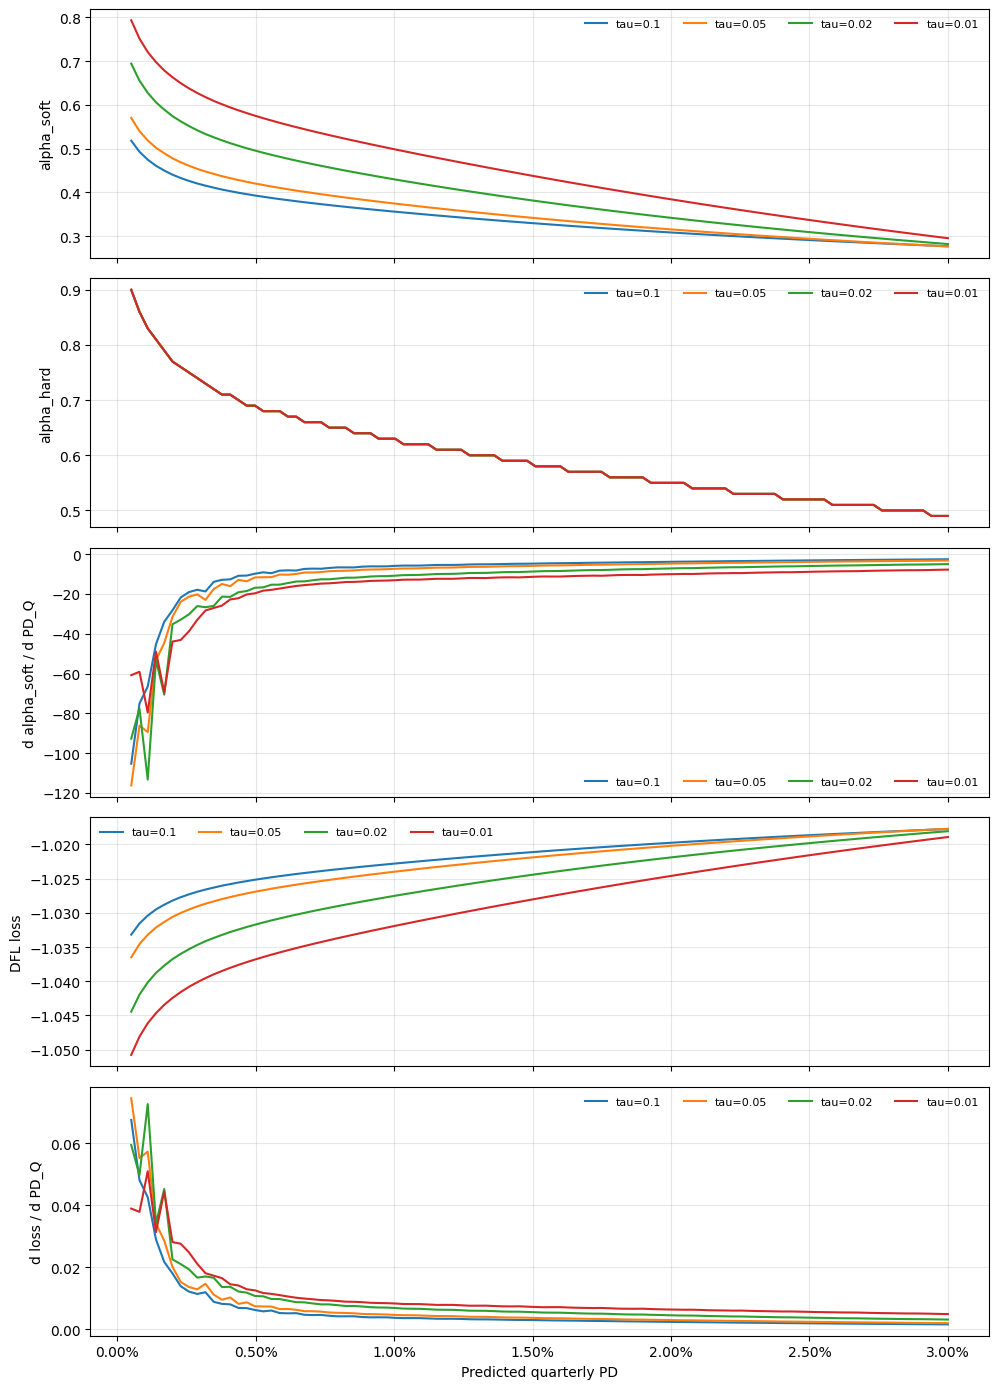

In [10]:
def sensitivity_for_temperature(
    pd_q_values: torch.Tensor,
    c_realised_fixed: float,
    temperature: float,
) -> Dict[str, torch.Tensor]:
    """Compute allocation/loss sensitivity over a grid of quarterly PD values."""
    pd_q_var = pd_q_values.clone().detach().requires_grad_(True)
    c_realised = torch.full_like(pd_q_var, c_realised_fixed)
    out = realised_dfl_loss_from_pd_q(pd_q_var, c_realised, alpha_grid, mc_shocks, temperature)

    alpha_grad = torch.autograd.grad(out["alpha_soft"].sum(), pd_q_var, retain_graph=True)[0]
    loss_grad = torch.autograd.grad(out["loss"], pd_q_var)[0]
    return {
        "pd_q": pd_q_var.detach(),
        "alpha_soft": out["alpha_soft"].detach(),
        "alpha_hard": out["alpha_hard"].detach(),
        "d_alpha_d_pd_q": alpha_grad.detach(),
        "loss_each": (-out["realised_utility"]).detach(),
        "d_loss_d_pd_q": loss_grad.detach(),
    }


pd_sensitivity_grid = torch.linspace(0.0005, 0.03, 100, dtype=DTYPE, device=DEVICE)
c_realised_fixed = 0.004
sens = {tau: sensitivity_for_temperature(pd_sensitivity_grid, c_realised_fixed, tau) for tau in temperatures}

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)
for tau, values in sens.items():
    pd_np = tensor_to_numpy(values["pd_q"])
    axes[0].plot(pd_np, tensor_to_numpy(values["alpha_soft"]), label=f"tau={tau}")
    axes[1].plot(pd_np, tensor_to_numpy(values["alpha_hard"]), label=f"tau={tau}")
    axes[2].plot(pd_np, tensor_to_numpy(values["d_alpha_d_pd_q"]), label=f"tau={tau}")
    axes[3].plot(pd_np, tensor_to_numpy(values["loss_each"]), label=f"tau={tau}")
    axes[4].plot(pd_np, tensor_to_numpy(values["d_loss_d_pd_q"]), label=f"tau={tau}")

axes[0].set_ylabel("alpha_soft")
axes[1].set_ylabel("alpha_hard")
axes[2].set_ylabel("d alpha_soft / d PD_Q")
axes[3].set_ylabel("DFL loss")
axes[4].set_ylabel("d loss / d PD_Q")
axes[4].set_xlabel("Predicted quarterly PD")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, ncol=4, fontsize=8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

## Optional smooth-shortfall comparison

The main specification uses `torch.relu(shortfall_gap)`. The diagnostic below compares it to a softplus approximation:

```text
softplus(kappa*x) / kappa
```

This is only a numerical diagnostic. It is not a squared shortfall penalty, and it does not replace the main economic specification.

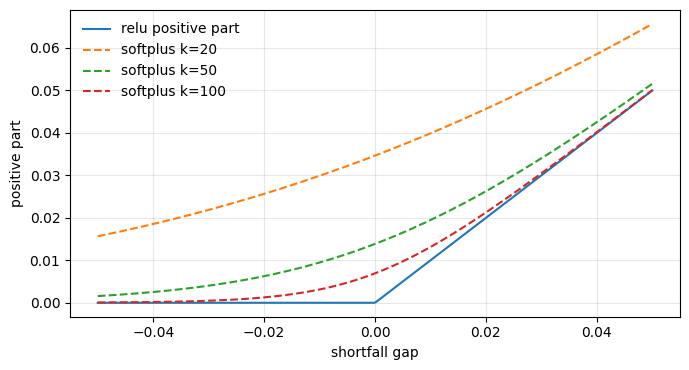

In [11]:
def smooth_shortfall_gap(gap: torch.Tensor, kappa: float = 50.0) -> torch.Tensor:
    """Smooth positive-part approximation, for diagnostics only."""
    return torch.nn.functional.softplus(kappa * gap) / kappa


gap_grid = torch.linspace(-0.05, 0.05, 300, dtype=DTYPE, device=DEVICE)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(tensor_to_numpy(gap_grid), tensor_to_numpy(torch.relu(gap_grid)), label="relu positive part")
for kappa in [20.0, 50.0, 100.0]:
    ax.plot(tensor_to_numpy(gap_grid), tensor_to_numpy(smooth_shortfall_gap(gap_grid, kappa)), linestyle="--", label=f"softplus k={kappa:g}")
ax.set_xlabel("shortfall gap")
ax.set_ylabel("positive part")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Conclusions and machine-readable diagnostics

The final dictionary summarises whether the decision layer is ready to connect to a forecasting network.

In [12]:
# Use the gradient-test outputs from above.
all_outputs_finite = all(
    bool(torch.isfinite(value).all().detach().cpu())
    for value in outputs.values()
    if isinstance(value, torch.Tensor)
)
gradient_exists = pd_q_manual.grad is not None
gradient_finite = bool(torch.isfinite(pd_q_manual.grad).all().detach().cpu()) if gradient_exists else False
gradient_nonzero = bool((torch.abs(pd_q_manual.grad) > 1e-10).any().detach().cpu()) if gradient_exists else False

# Pick the lowest finite-difference relative difference as a simple recommended temperature.
recommended_temperature = float(fd_table.sort_values(["relative_difference", "absolute_difference"]).iloc[0]["temperature"])

# Basic instability flags from sensitivity curves.
gradient_sensitivity = []
for tau, values in sens.items():
    loss_grad = values["d_loss_d_pd_q"]
    alpha_grad = values["d_alpha_d_pd_q"]
    gradient_sensitivity.append({
        "temperature": tau,
        "max_abs_d_loss_d_pd_q": float(torch.max(torch.abs(loss_grad)).cpu()),
        "share_near_zero_d_alpha": float((torch.abs(alpha_grad) < 1e-8).to(DTYPE).mean().cpu()),
    })
gradient_sensitivity_table = pd.DataFrame(gradient_sensitivity)
display(gradient_sensitivity_table)

diagnostics = {
    "all_outputs_finite": all_outputs_finite,
    "gradient_exists": gradient_exists,
    "gradient_finite": gradient_finite,
    "gradient_nonzero": gradient_nonzero,
    "finite_difference_check_passed": finite_difference_check_passed,
    "recommended_temperature": recommended_temperature,
}
print(diagnostics)

print("\nDiagnostic answers:")
print("1. Basel IRB pipeline differentiable:", all_outputs_finite and gradient_exists and gradient_finite)
print("2. Vasicek expected utility differentiable:", all_outputs_finite and gradient_nonzero)
print("3. Soft allocation produces nonzero gradients:", gradient_nonzero)
print("4. Most stable temperature by finite-difference check:", recommended_temperature)
print("5. Gradient sensitivity table highlights near-zero and large-gradient regions above.")
print("6. Ready to connect to forecasting network:", all(diagnostics[k] for k in ["all_outputs_finite", "gradient_exists", "gradient_finite", "gradient_nonzero", "finite_difference_check_passed"]))

,temperature,max_abs_d_loss_d_pd_q,share_near_zero_d_alpha
0,0.10,0.067440,0.0
1,0.05,0.074430,0.0
2,0.02,0.072548,0.0
3,0.01,0.050957,0.0


{'all_outputs_finite': True, 'gradient_exists': True, 'gradient_finite': True, 'gradient_nonzero': True, 'finite_difference_check_passed': True, 'recommended_temperature': 0.1}

Diagnostic answers:
1. Basel IRB pipeline differentiable: True
2. Vasicek expected utility differentiable: True
3. Soft allocation produces nonzero gradients: True
4. Most stable temperature by finite-difference check: 0.1
5. Gradient sensitivity table highlights near-zero and large-gradient regions above.
6. Ready to connect to forecasting network: True
